In [1]:
from autoenkoop import *
import torch
import numpy as np
import pandas as pd
import os
from matplotlib.colors import Normalize
from tqdm import tqdm

In [2]:
datafile = np.load(os.path.join("..", "data", "T1492_x1151_y1_z127_c2.npz"))
data = datafile['timeseries']
print(data.shape)

(vx_min, vx_max), (vz_min, vz_max) = get_min_max(data)
norm_x = Normalize(vmin=vx_min, vmax=vx_max)
norm_z = Normalize(vmin=vz_min, vmax=vz_max)

(1493, 1151, 127, 2)


In [112]:
results_path = os.path.join("..", "results")
#run_path = os.path.join(results_path, "koopman_autoencoder_classic", "lambda_001")
run_path = os.path.join(results_path, "koopman_autoencoder_directK_linerror_tracking", "L1_e20_lr0.001_fbK_lossEqual")
#run_path = os.path.join(results_path, "koopman_autoencoder_multistep_exponential", "L128_a20_e300_lr0.0003_st5_norm")

In [113]:
lifted_state_history = np.load(os.path.join(run_path, "lifted_state_history.npy"))
K_history = np.load(os.path.join(run_path, "K.npy"))

In [114]:
K_history.shape

(20, 1, 1)

In [115]:
import pydmd
from pydmd.plotter import plot_summary
dmd_exact = pydmd.DMD(-1, forward_backward=True)

[[0.99981252]]
[0.99924052]


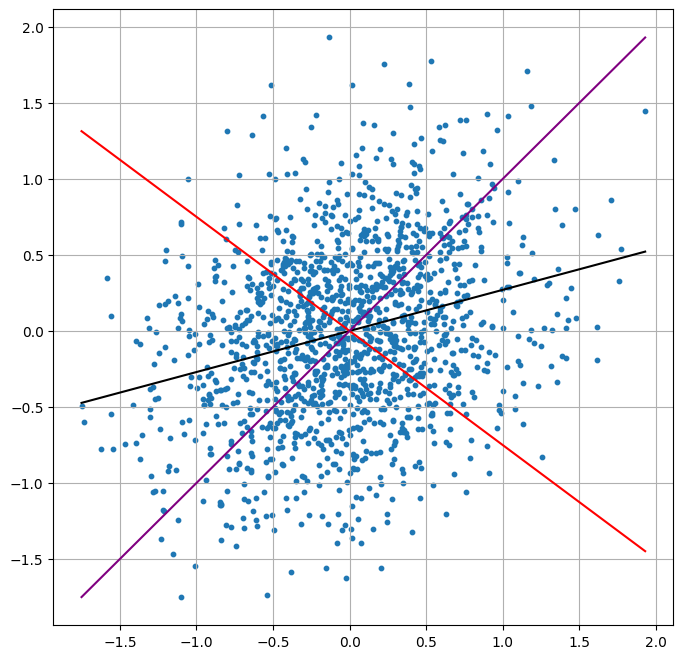

[[1.00034284]]
[0.99924052]


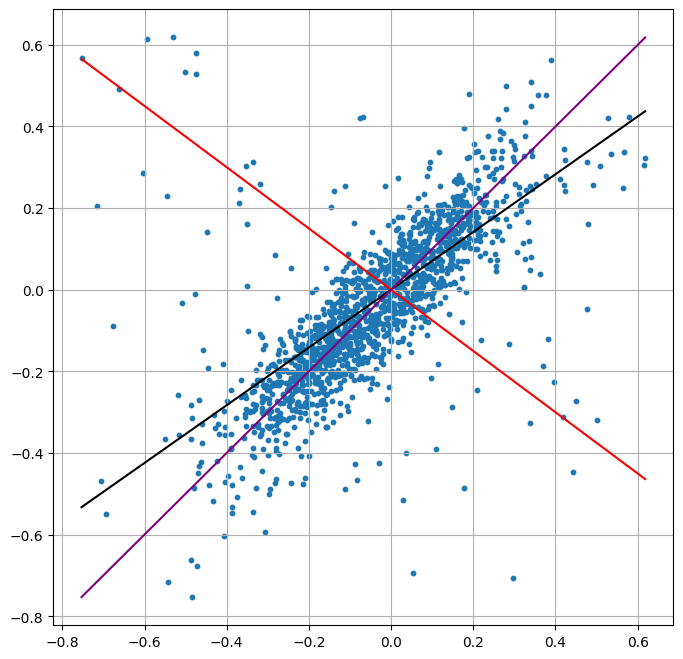

[[0.9998021]]
[0.99924052]


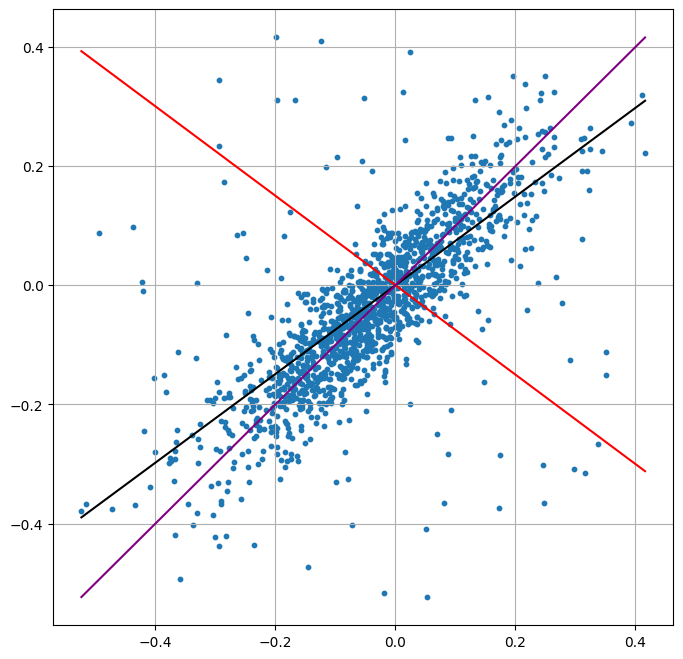

[[1.00002615]]
[0.99924052]


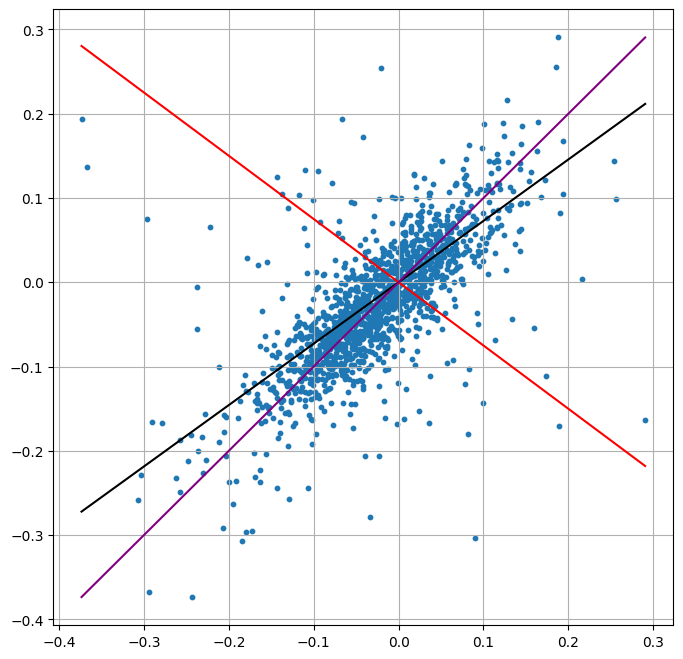

[[1.00073616]]
[0.99924052]


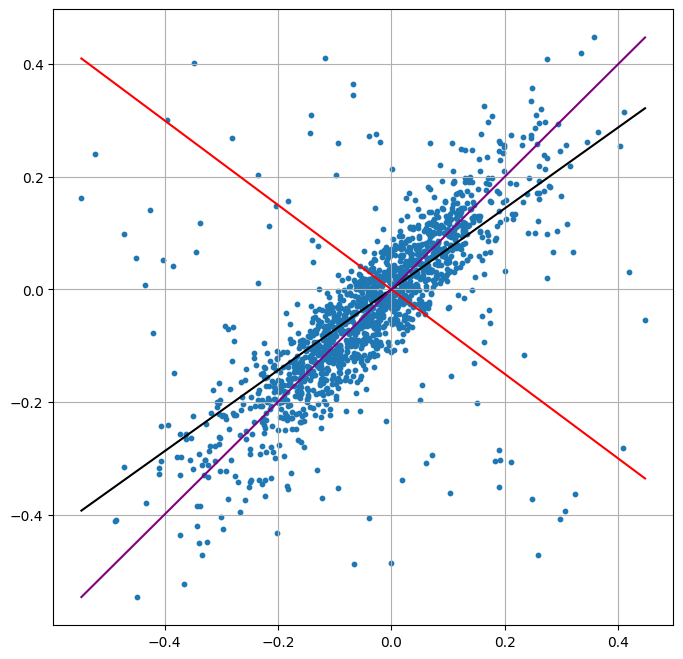

[[1.00106671]]
[0.99924052]


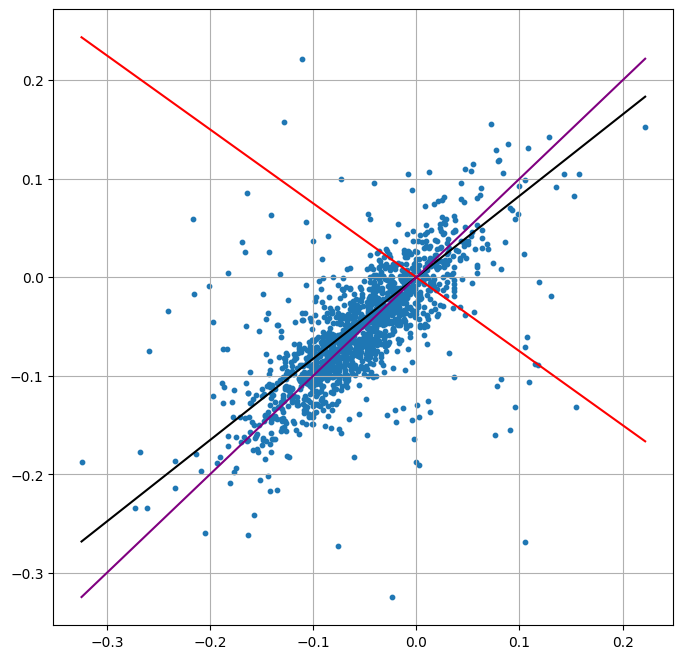

[[1.00012475]]
[0.99924052]


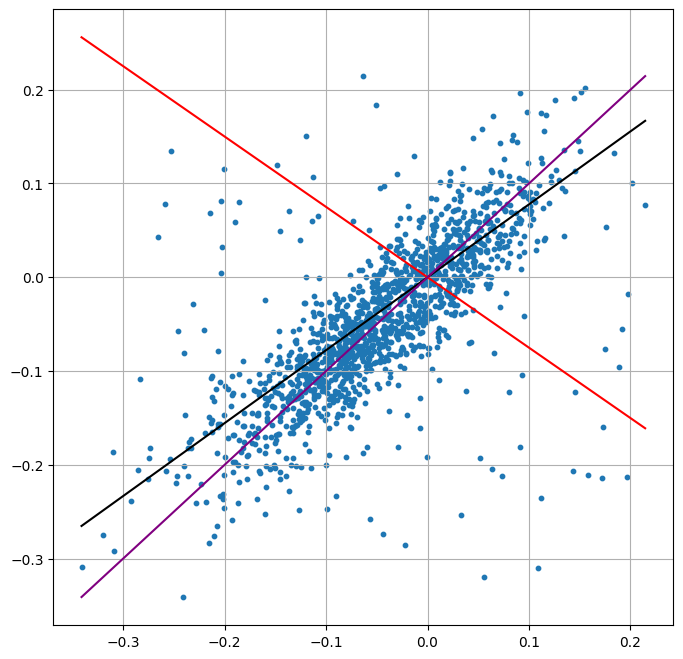

[[1.00028827]]
[0.99924052]


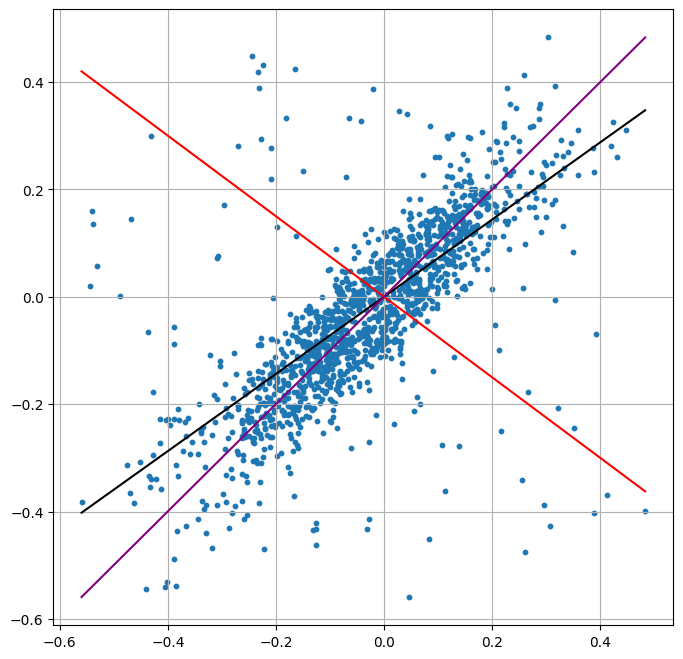

[[1.00106582]]
[0.99924052]


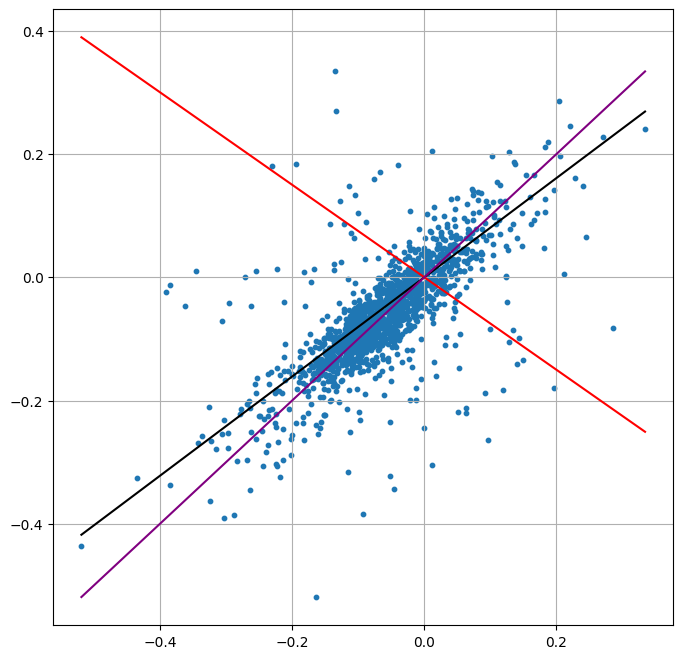

[[1.00136595]]
[0.99924052]


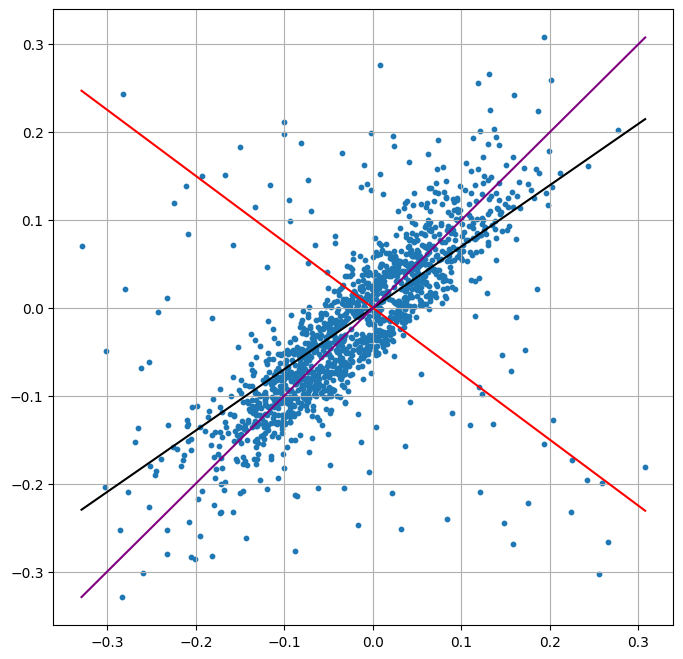

[[1.00003707]]
[0.99924052]


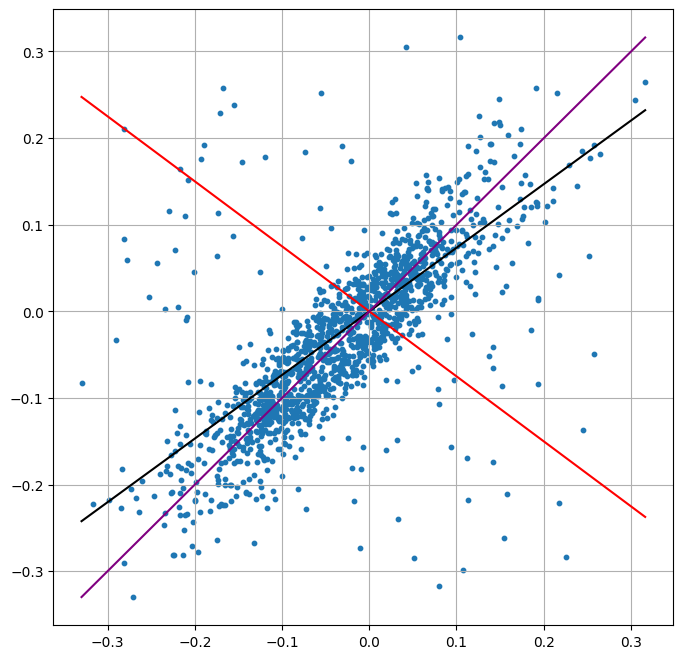

[[0.99699647]]
[0.99924052]


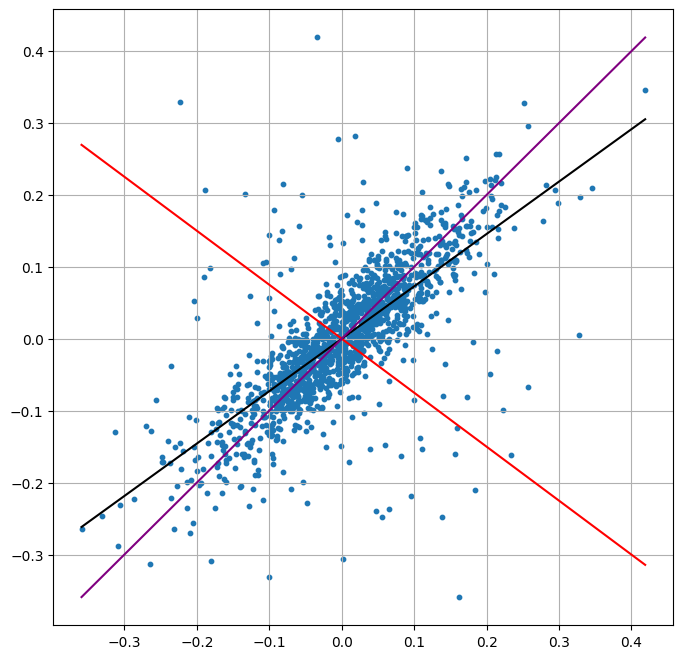

[[1.00208659]]
[0.99924052]


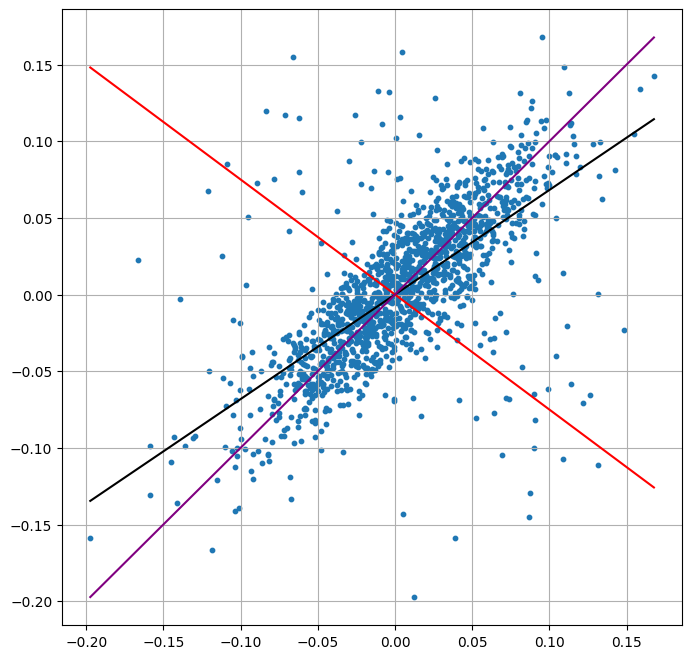

[[0.99942501]]
[0.99924052]


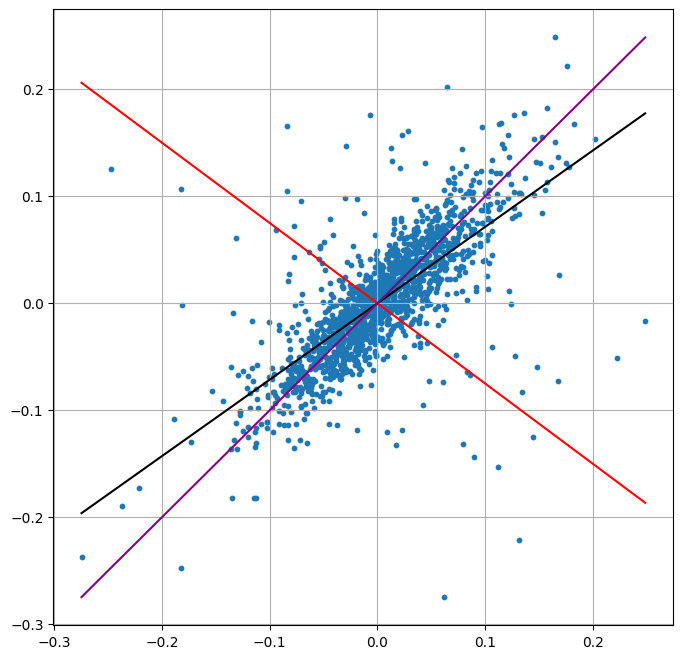

[[1.00002327]]
[0.99924052]


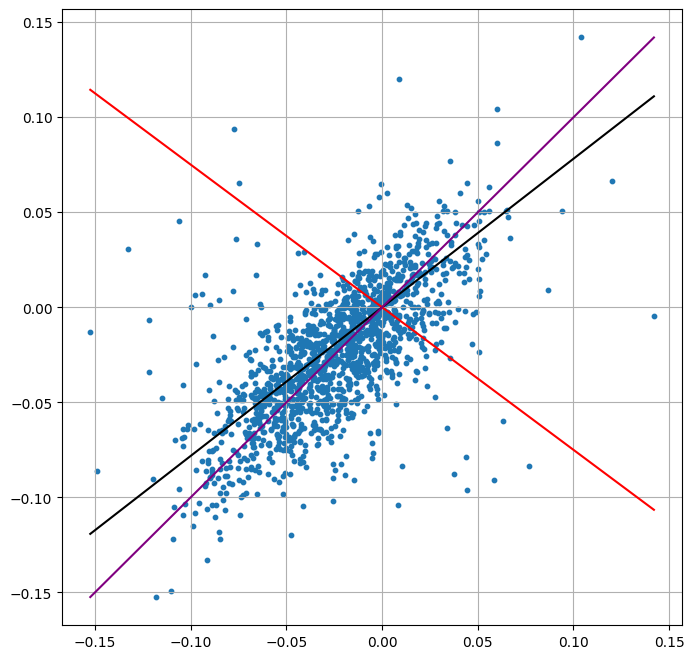

[[0.99934938]]
[0.99924052]


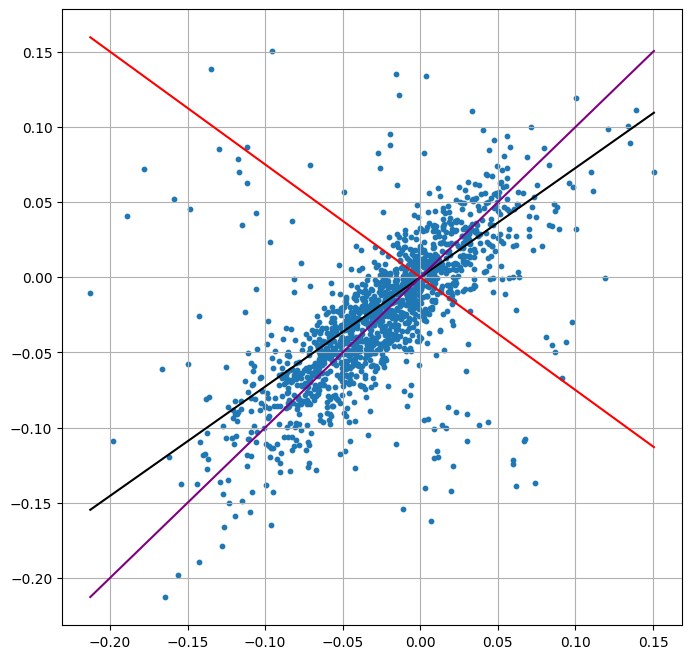

[[0.99991503]]
[0.99924052]


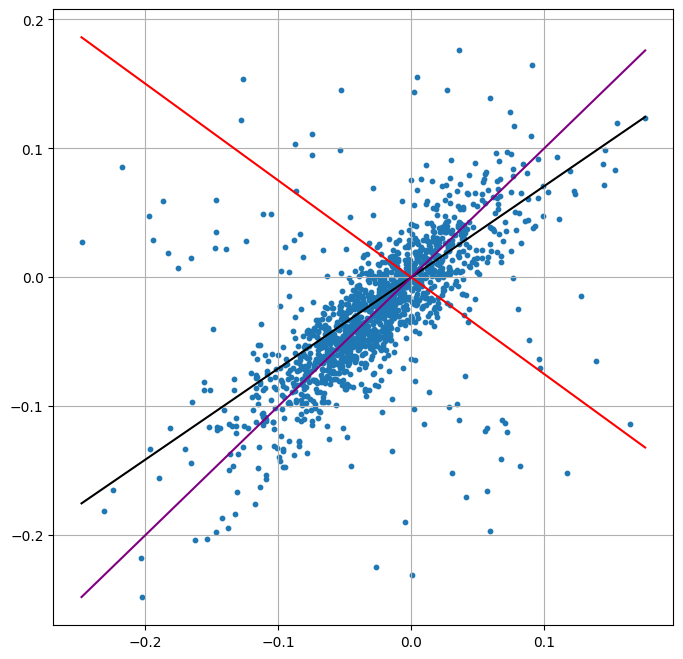

[[0.9999431]]
[0.99924052]


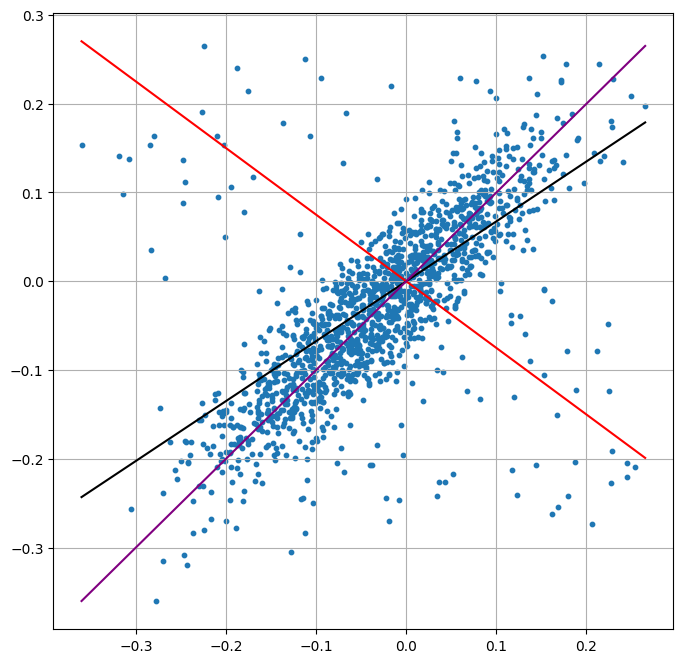

[[0.99869254]]
[0.99924052]


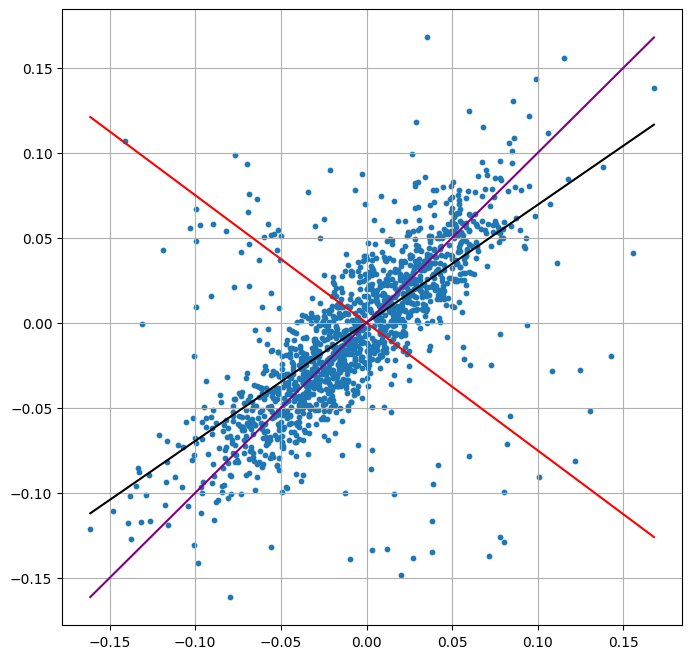

[[1.00164672]]
[0.99924052]


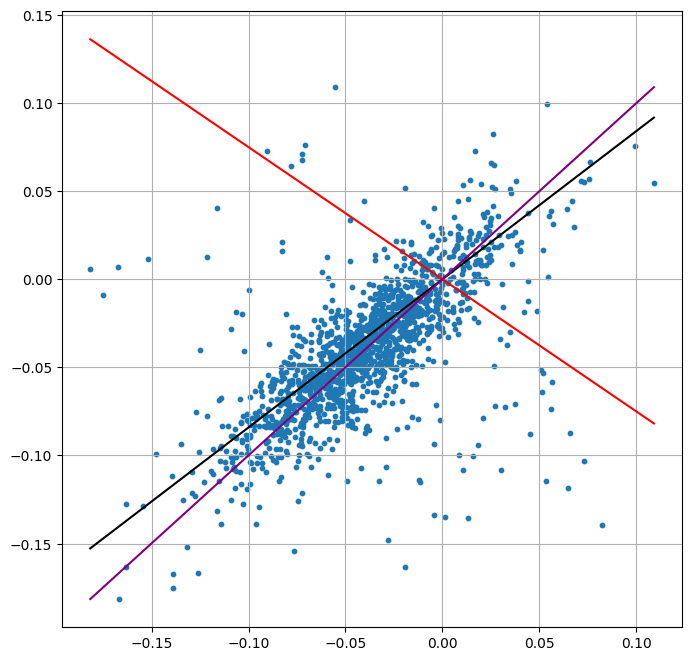

In [117]:
for epoch in range(20):
    Z_all = lifted_state_history[epoch]
    minZ, maxZ = np.min(Z_all), np.max(Z_all)
    z_span = np.array([minZ, maxZ])
    
    Z0 = Z_all[:-1].T
    Z1 = Z_all[1:].T
    
    dmd_exact.fit(Z_all.T)
    K_exact = dmd_exact.modes @ np.diag(dmd_exact.eigs) @ np.linalg.pinv(dmd_exact.modes)
    print(K_exact)
    print(K_exact_slope)
    K_exact_slope
    K_star = Z1 @ np.linalg.pinv(Z0)
    K = K_history[epoch]
    K_star_slope = K_star[0][0]
    K_slope = K[0][0]
    
    plt.figure(figsize=(8,8))
    plt.grid()
    plt.scatter(Z0, Z1, s=10)
    plt.plot(z_span, z_span*K_star_slope, color="black")
    plt.plot(z_span, z_span*K_slope, color="red")
    plt.plot(z_span, z_span*K_exact_slope, color="purple")
    plt.show()

In [15]:
LATENT_DIMENSION = 128
DEVICE = "cpu"#"cuda" if torch.cuda.is_available() else "cpu"
kae_model = ConvAutoencoderKoop(latent_dim=LATENT_DIMENSION).to(DEVICE)

In [16]:
kae_model.load_state_dict(torch.load(os.path.join(run_path, "model.pt"), map_location=DEVICE))
kae_model.eval()

ConvAutoencoderKoop(
  (encoder): Sequential(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): GELU(approximate='none')
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): GELU(approximate='none')
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): GELU(approximate='none')
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): GELU(approximate='none')
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): Flatten(start_dim=1, end_dim=-1)
    (13): Linear(in_features=73728, out_features=1024, bias=True)
    (14): GELU(approximate='none')
    (15): Batch

In [17]:
permuted_data = torch.tensor(data, dtype=torch.float32).permute(0,3,1,2)

In [18]:
lifted_states = []

with torch.no_grad():
    for x_t in permuted_data:
        z_t = kae_model.encoder(x_t.unsqueeze(0))
        lifted_states.append(z_t.squeeze(0).numpy())

In [19]:
lifted_states = np.array(lifted_states)

In [ ]:
import pydmd
dmd_exact = pydmd.DMD(-1, exact=True, tikhonov_regularization=0.001)

In [ ]:
dmd_exact.fit(lifted_states.T)

In [ ]:
eigenvaluesB = dmd_exact.eigs
eigenvectorsB = dmd_exact.modes
energiesB = eigenvalue_energies(kae_model, eigenvectorsB, DEVICE)

In [ ]:
plot_eigenvalue_spectrum(eigenvaluesB, eigenvectorsB, energiesB)

In [20]:
X = lifted_states[:-1,:].T
X_shift = lifted_states[1:,:].T

In [21]:
A = X_shift @ np.linalg.pinv(X)

In [22]:
eigvalsA, eigvecsA = get_sorted_eigen(A)

In [23]:
energiesA = eigenvalue_energies(kae_model, eigvecsA, DEVICE)

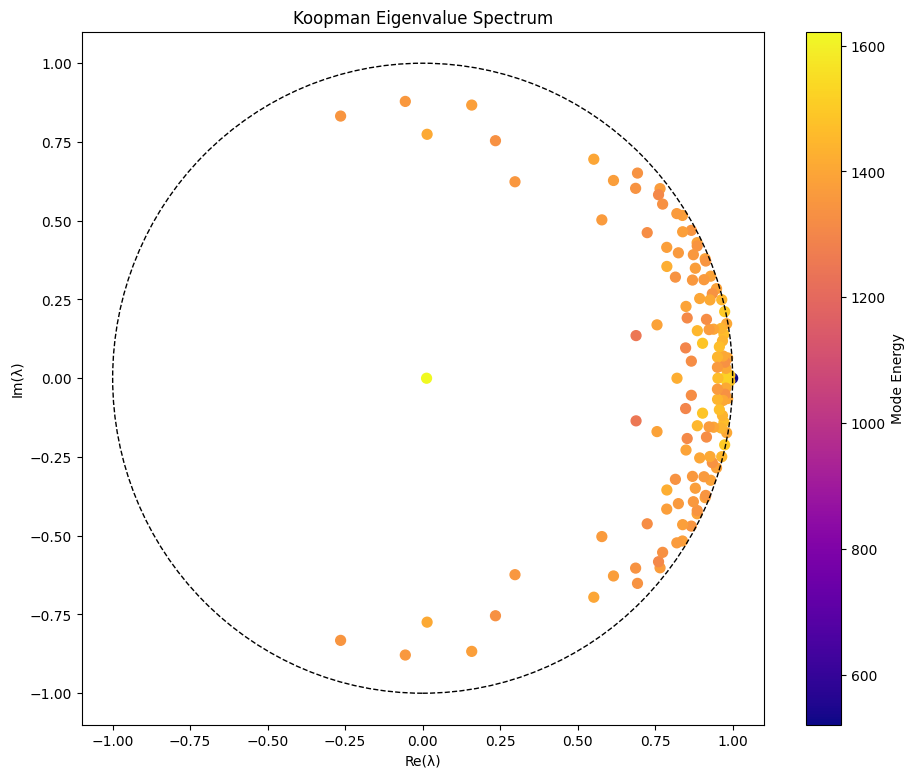

In [24]:
plot_eigenvalue_spectrum(eigvalsA, eigvecsA, energiesA)

In [ ]:
with torch.no_grad():
    K = kae_model.linear_dynamics.weight.detach().cpu().numpy()
eigvals, eigvecs = get_sorted_eigen(K)

In [ ]:
energies = eigenvalue_energies(kae_model, eigvecs, DEVICE)

In [ ]:
plot_eigenvalue_spectrum(eigvals, eigvecs, energies)

In [27]:
steady_tolerance = 0.01

stable_values, stable_vectors, stable_energies = get_stable_modes(eigvalsA, eigvecsA, energiesA, steady_tolerance, False)

9 stable mode explain: 6.92% of the energy


In [ ]:
def prediction_mse(data, start_index, prediction_length, eigenvalues, eigenvectors, model):
    x0 = torch.tensor(data[start_index]).permute(2,0,1).unsqueeze(0)
    stable_predicted_trajectory = predict_trajectory_reduced(x0, model, eigenvalues, eigenvectors, prediction_length)
    stable_predicted_trajectory = np.array(stable_predicted_trajectory).reshape(prediction_length, -1)
    true_trajectory = np.permute_dims(data[start_index:start_index+prediction_length], (0,3,1,2)).reshape(prediction_length, -1)
    mse = np.mean((stable_predicted_trajectory - true_trajectory)**2, 1)
    return mse

In [ ]:
window = 100

mse_list = []
for i in tqdm(range(len(data)-window)):
    mse_list.append(prediction_mse(data, i, window, stable_values, stable_vectors, kae_model))
mse_array112_new = np.array(mse_list)

In [ ]:
#global_mse27_mean = np.mean(mse_array, 0)
#global_mse9_mean = np.mean(mse_array9, 0)
#global_mse128_mean = np.mean(mse_array128, 0)
global_mse_array112_new = np.mean(mse_array112_new, 0)
#global_mse_std = np.std(mse_array, 0)

In [ ]:
#lower_gmse = global_mse_mean - global_mse_std
#upper_gmse = global_mse_mean + global_mse_std
plot_evolution([global_mse_array112_new], ["(112 modes)"], "window-mean MSE of reduced models", "time step", "mse")

In [ ]:
plot_evolution([global_mse128_mean, global_mse27_mean, global_mse9_mean], ["(128 modes, full)","(27 modes)", "(9 modes)"], "window-mean MSE of reduced models", "time step", "mse")

In [ ]:
timestep_mse = np.mean(mse_array, 1)

In [ ]:
plot_evolution([timestep_mse], ["timestep mse"], "MSE(predicted, real) over timesteps", "time step", "error")

In [ ]:
x_t_stable = stable_predicted_trajectory[300]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
animate_trajectory(stable_predicted_trajectory, "model_new_27normalized_modes_1000", norm_x, norm_z)

In [28]:
def filter_pos_imag(values, vectors, energies):
    mode_mask = values.imag >= 0
    mode_vectors = vectors[:, mode_mask]
    mode_values = values[mode_mask]
    mode_energies = energies[mode_mask]
    return mode_values, mode_vectors, mode_energies

def calculate_eigenmode_structures(eigenvectors, model, device = "cpu"):
    modes = []
    with torch.no_grad():
        for vec in eigenvectors.T:
            modes.append(model.decoder(torch.FloatTensor(vec.real).unsqueeze(0).to(device)).squeeze(0).cpu().numpy())
    return modes

In [29]:
mode_values, mode_vectors, mode_energies = filter_pos_imag(stable_values, stable_vectors, stable_energies)

(1.0000041723251343+0j) 	 1.0000041723251343
520.2489013671875


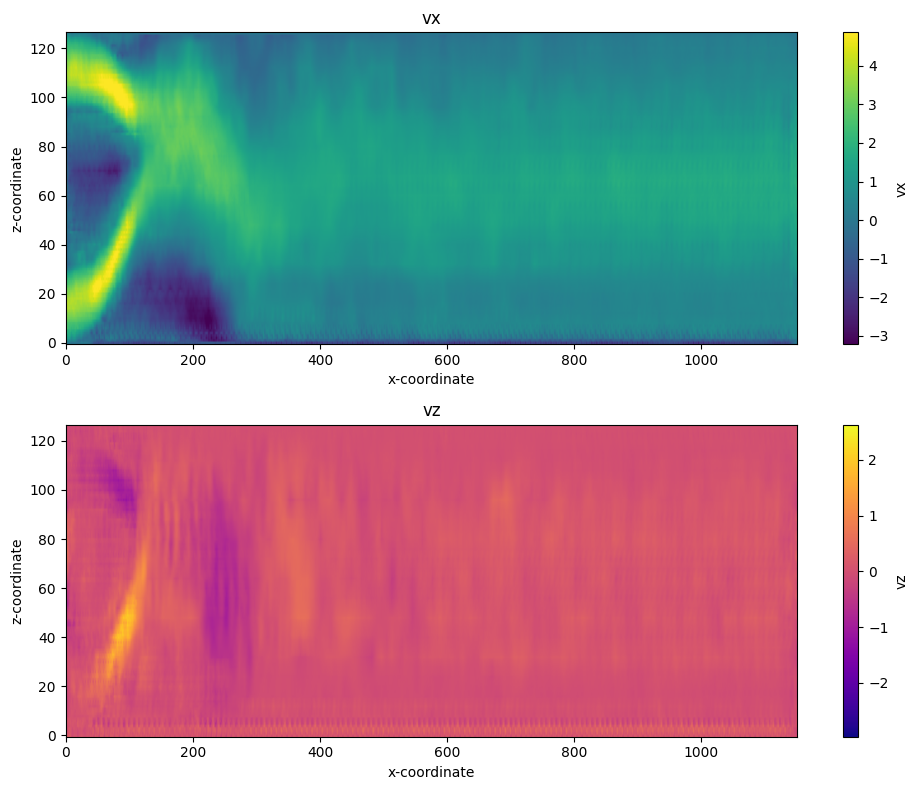

(0.9742305874824524+0.21142902970314026j) 	 0.9969089588260384
1500.579345703125


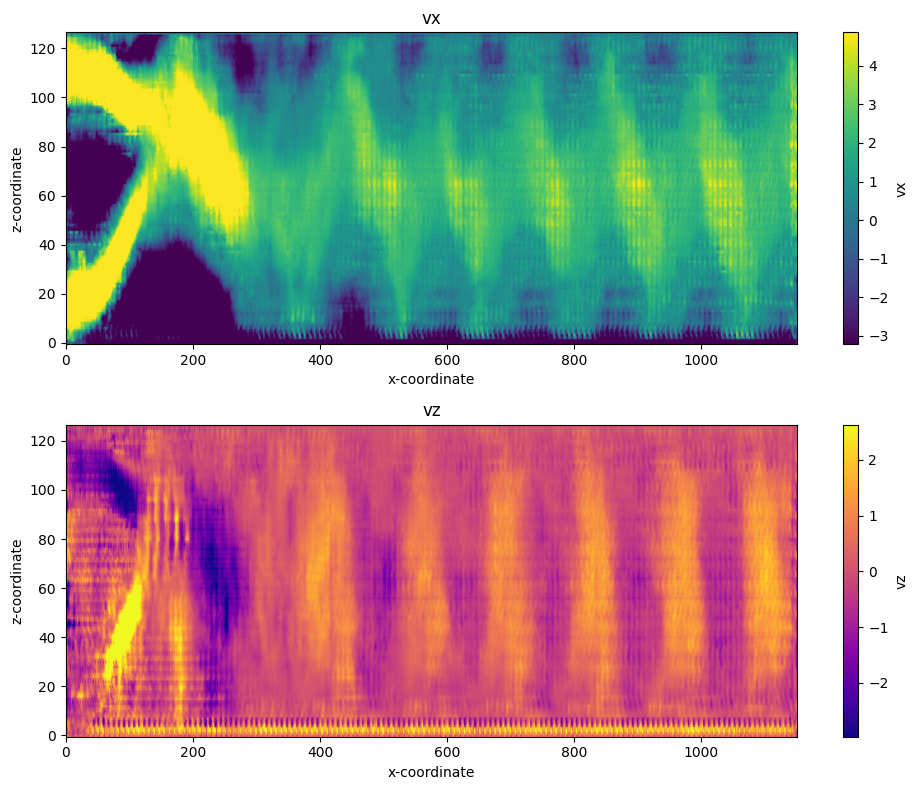

(0.9647607803344727+0.24919617176055908j) 	 0.9964246561038616
1449.105224609375


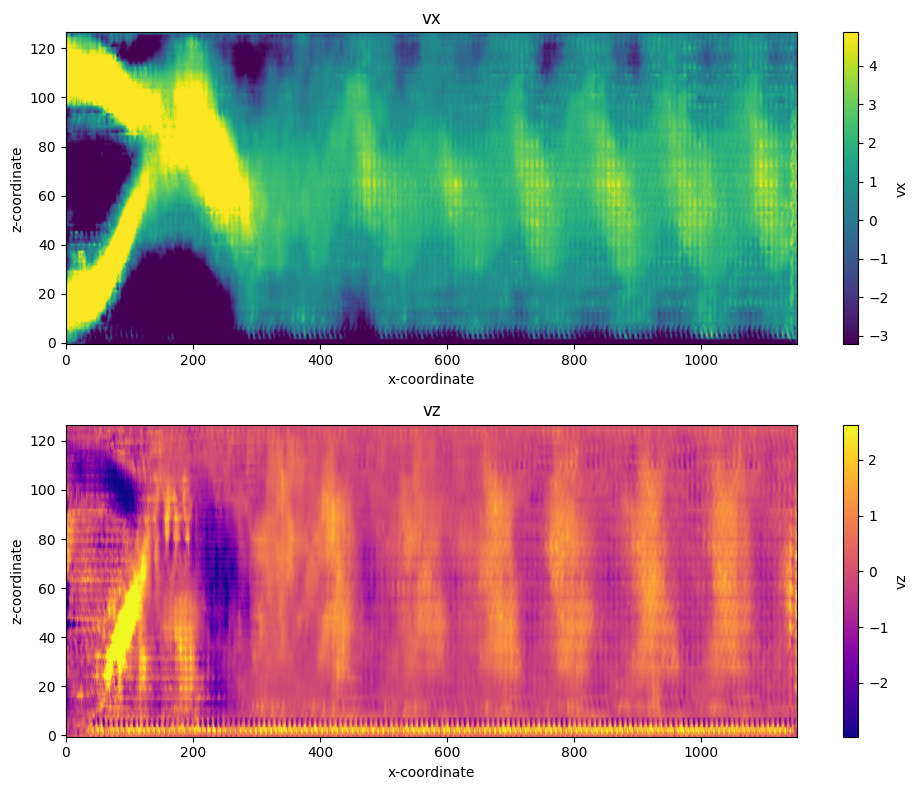

(0.9806678891181946+0.17305535078048706j) 	 0.9958200957910485
1405.9737548828125


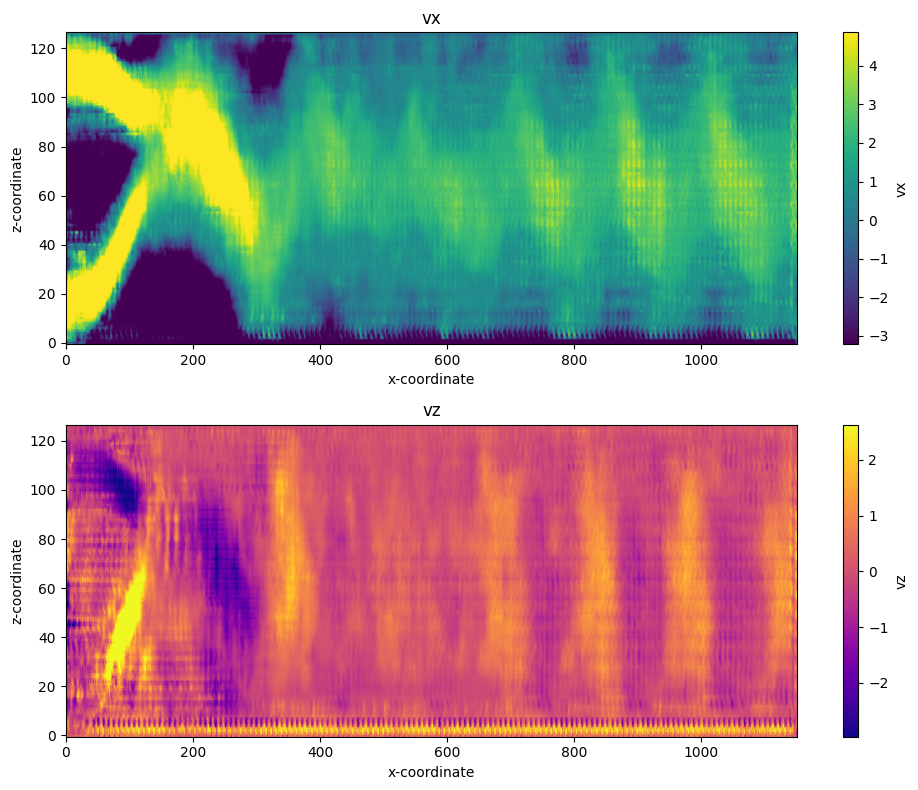

(0.9906854629516602+0.009316193871200085j) 	 0.990729265729034
1492.00341796875


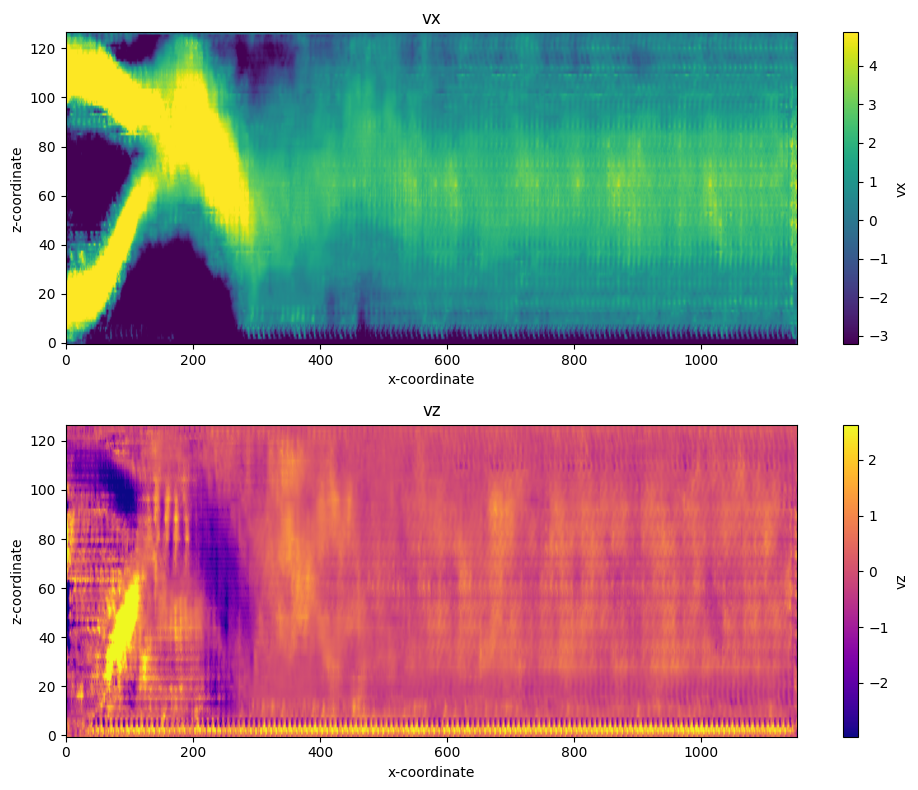

In [30]:
stable_structures = calculate_eigenmode_structures(mode_vectors, kae_model)
for i, structure in enumerate(stable_structures):
    print(mode_values[i].item(),"\t", np.abs(mode_values[i].item()))
    print(mode_energies[i])
    vx = structure[0,:]
    vz = structure[1,:]
    plot_vx_vz(vx, vz, norm_x, norm_z)

In [ ]:
x0, _ = dataset[0]
x0 = x0.unsqueeze(0).to(DEVICE)
with torch.no_grad():
    z0 = kae_model.encoder(x0)

z0 = z0.squeeze(0).to(torch.complex64)
# Compute coefficients in modal basis
c0 = torch.linalg.pinv(V_nondecay) @ z0

def koopman_evolve(t):
    Lambda_t_diag = torch.diag(torch.exp(torch.log(E_nondecay_normalized) * t))
    z_t_complex = V_nondecay @ Lambda_t_diag @ c0
    return z_t_complex.real.unsqueeze(0)

def reconstruct_state(t):
    z_t_predicted = koopman_evolve(t)
    x_t_reconstructed = kae_model.decoder(z_t_predicted)
    return x_t_reconstructed.squeeze(0)

AttributeError: 'numpy.ndarray' object has no attribute 'unsqueeze'

In [ ]:
steady_state_prediction = []
with torch.no_grad():
    for t in range(1500):
        reconstructed_x_t = reconstruct_state(t).cpu().numpy()
        steady_state_prediction.append(reconstructed_x_t)

In [ ]:
x_t_stable = steady_state_prediction[1000]
vx = x_t_stable[0,:]
vz = x_t_stable[1,:]

plot_vx_vz(vx, vz)

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter

#n_timesteps = len(steady_state_prediction)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Initialize first frame
vx = data[0, :, :, 0]
vz = data[0, :, :, 1]

im_vx = axes[0].imshow(vx.T, origin='lower', aspect='auto', cmap='viridis', norm=norm_x)
axes[0].set_title("vx at time frame 0")
axes[0].set_xlabel("x-coordinate")
axes[0].set_ylabel("z-coordinate")
fig.colorbar(im_vx, ax=axes[0], label="vx")

im_vz = axes[1].imshow(vz.T, origin='lower', aspect='auto', cmap='plasma', norm=norm_z)
axes[1].set_title("vz")
axes[1].set_xlabel("x-coordinate")
axes[1].set_ylabel("z-coordinate")
fig.colorbar(im_vz, ax=axes[1], label="vz")

plt.tight_layout()

def update(frame):
    print(frame)
    vx = data[frame, :, :, 0]
    vz = data[frame, :, :, 1]
    
    im_vx.set_data(vx.T)
    im_vz.set_data(vz.T)
    
    axes[0].set_title(f"vx at time frame {frame}")
    #axes[1].set_title(f"vz")
    
    return [im_vx, im_vz]

ani = FuncAnimation(fig, update,
                    frames=range(data.shape[0]),
                    interval=30,
                    blit=False)

# Save as GIF (requires Pillow)
writer = PillowWriter(fps=20)
ani.save("velocity_field_true_full.gif", writer=writer)

plt.show()